In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/scoring"
    !pip install -q interpret shap fairlearn lightgbm xgboost mlflow
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)  # MLflow tracking URI is relative to cwd
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")

# Phase 6: MLOps — Experiment Tracking, Model Registry & Drift Monitoring

In [2]:
import pandas as pd, numpy as np, joblib, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from mlflow import MlflowClient
warnings.filterwarnings("ignore")

from src.models import build_lr, build_xgb, build_lgbm, build_ebm
from src.evaluate import compute_metrics, metrics_table, compute_performance_over_time
from src.mlflow_utils import setup_experiment, log_training_run
from src.drift import compute_psi, compute_ks_test, compute_drift_report, simulate_drift
from src.pltr import PLTR

# Load raw CSVs — all saved models are now sklearn Pipelines that accept raw DataFrames
X_train = pd.read_csv(os.path.join(DATA_DIR, "processed", "X_train_raw.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "processed", "y_train.csv")).squeeze()
X_test = pd.read_csv(os.path.join(DATA_DIR, "processed", "X_test_raw.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "processed", "y_test.csv")).squeeze()

# Load top 10 features and optimal thresholds
top10 = pd.read_csv(os.path.join(REPORTS_DIR, "top10_features.csv")).squeeze().tolist()
thresholds = pd.read_csv(os.path.join(REPORTS_DIR, "optimal_thresholds.csv"), index_col=0).squeeze()

X_train_10 = X_train[top10]
X_test_10 = X_test[top10]

print(f"Data loaded: train {X_train.shape}, test {X_test.shape}")
print(f"Top 10 features: {top10}")
print(f"Thresholds: {thresholds.to_dict()}")

Data loaded: train (684592, 61), test (1096128, 61)
Top 10 features: ['int_rate', 'term', 'acc_open_past_24mths', 'annual_inc', 'dti', 'fico', 'loan_amnt', 'tot_hi_cred_lim', 'avg_cur_bal', 'total_bc_limit']
Thresholds: {'LR': 0.4893350440010683, 'XGB': 0.471260517835617, 'LGBM': 0.4717619726662763, 'EBM': 0.1744859734029999, 'NeuralNet': 0.4834242165088653}


## 6.1 Experiment Tracking — Baseline Models (75 Features)

Log all Phase 2 baseline models to MLflow. Models are loaded from saved artifacts (not retrained).

In [3]:
setup_experiment("baseline-75-features")

# Baseline models are now sklearn Pipelines stored as lr.pkl, xgb.pkl, lgbm.pkl, ebm.pkl
# (the *_baseline.pkl files are plain models from an older pipeline and no longer usable
#  with X_test_raw — switch to the Pipeline versions which accept raw DataFrames)

# --- Logistic Regression ---
lr = joblib.load(os.path.join(MODELS_DIR, "lr.pkl"))
run_id_lr_75 = log_training_run(
    model=lr, model_name="LogisticRegression",
    X_test=X_test, y_test=y_test,
    params={"solver": "lbfgs", "max_iter": 1000, "class_weight": "balanced"},
    optimal_threshold=float(thresholds["LR"]),
)
print(f"LR logged: {run_id_lr_75}")

# --- XGBoost ---
xgb = joblib.load(os.path.join(MODELS_DIR, "xgb.pkl"))
run_id_xgb_75 = log_training_run(
    model=xgb, model_name="XGBoost",
    X_test=X_test, y_test=y_test,
    params={"eval_metric": "logloss", "scale_pos_weight": round((y_train == 0).sum() / (y_train == 1).sum(), 2)},
    optimal_threshold=float(thresholds["XGB"]),
    artifacts={"shap_beeswarm": os.path.join(REPORTS_DIR, "shap_beeswarm.png"),
               "shap_bar": os.path.join(REPORTS_DIR, "shap_bar.png")},
)
print(f"XGB logged: {run_id_xgb_75}")

# --- LightGBM ---
lgbm = joblib.load(os.path.join(MODELS_DIR, "lgbm.pkl"))
run_id_lgbm_75 = log_training_run(
    model=lgbm, model_name="LightGBM",
    X_test=X_test, y_test=y_test,
    params={"scale_pos_weight": round((y_train == 0).sum() / (y_train == 1).sum(), 2), "verbose": -1},
    optimal_threshold=float(thresholds["LGBM"]),
)
print(f"LGBM logged: {run_id_lgbm_75}")

# --- EBM ---
ebm = joblib.load(os.path.join(MODELS_DIR, "ebm.pkl"))
run_id_ebm_75 = log_training_run(
    model=ebm, model_name="EBM",
    X_test=X_test, y_test=y_test,
    params={"max_rounds": 10000},
    optimal_threshold=float(thresholds["EBM"]),
)
print(f"EBM logged: {run_id_ebm_75}")

print("\n=== All 75-feature Pipeline models logged to MLflow ===")

2026/04/19 18:58:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/19 18:58:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR logged: 4cbfba7871334b9ebd20517fc2846df3


2026/04/19 19:06:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/19 19:06:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/04/19 19:13:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LGBM logged: 278570ced2cb4debb7d2b11bbefb0bf6


2026/04/19 19:21:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/19 19:21:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


EBM logged: 4fb601f7ff694035b4b10ba50974c5cd

=== All 75-feature Pipeline models logged to MLflow ===


## 6.2 Experiment Tracking — Reduced Models (Top 10 Features)

In [4]:
setup_experiment("reduced-10-features")

from sklearn.metrics import roc_curve

# Helper: compute optimal threshold
def optimal_threshold(y_true, y_prob):
    fpr, tpr, thrs = roc_curve(y_true, y_prob)
    return thrs[np.argmax(tpr - fpr)]

# --- LR ---
lr_10 = joblib.load(os.path.join(MODELS_DIR, "lr_top10.pkl"))
y_prob = lr_10.predict_proba(X_test_10)[:, 1]
t_lr = optimal_threshold(y_test, y_prob)
run_id_lr_10 = log_training_run(
    model=lr_10, model_name="LogisticRegression",
    X_test=X_test_10, y_test=y_test,
    params={"solver": "lbfgs", "max_iter": 1000, "class_weight": "balanced"},
    optimal_threshold=float(t_lr),
)
print(f"LR (10) logged: {run_id_lr_10}")

# --- XGBoost ---
xgb_10 = joblib.load(os.path.join(MODELS_DIR, "xgb_top10.pkl"))
y_prob = xgb_10.predict_proba(X_test_10)[:, 1]
t_xgb = optimal_threshold(y_test, y_prob)
from src.fairness import bin_continuous
import numpy as _np
import pandas as _pd

_sm = {
    "home_owner":  X_test["home_ownership"],
    "fico_bin":    bin_continuous(X_test["fico"], bins=4),
    "income_bin":  bin_continuous(X_test["annual_inc"], bins=4),
}
_int_rate = X_test["int_rate"]
_int_rates = (_int_rate / 100.0 if _int_rate.median() > 1.0 else _int_rate).to_numpy(dtype=float)
_terms = _pd.to_numeric(X_test["term"].astype(str).str.extract(r"(\d+)")[0], errors="coerce").to_numpy(dtype=float)
_recoveries = X_test.get("recoveries", _pd.Series(_np.zeros(len(X_test)))).fillna(0.0).to_numpy(dtype=float)

run_id_xgb_10 = log_training_run(
    model=xgb_10, model_name="XGBoost",
    X_test=X_test_10, y_test=y_test,
    params={"eval_metric": "logloss", "scale_pos_weight": round((y_train == 0).sum() / (y_train == 1).sum(), 2)},
    optimal_threshold=float(t_xgb),
    threshold_strategy="expected_profit",
    threshold_kwargs={
        "loan_amnts": X_test["loan_amnt"].to_numpy(dtype=float),
        "int_rates": _int_rates,
        "terms": _terms,
        "recoveries": _recoveries,
    },
    sensitive_map=_sm,
)
print(f"XGB (10) logged: {run_id_xgb_10}")

# --- LightGBM ---
lgbm_10 = joblib.load(os.path.join(MODELS_DIR, "lgbm_top10.pkl"))
y_prob = lgbm_10.predict_proba(X_test_10)[:, 1]
t_lgbm = optimal_threshold(y_test, y_prob)
run_id_lgbm_10 = log_training_run(
    model=lgbm_10, model_name="LightGBM",
    X_test=X_test_10, y_test=y_test,
    params={"scale_pos_weight": round((y_train == 0).sum() / (y_train == 1).sum(), 2), "verbose": -1},
    optimal_threshold=float(t_lgbm),
)
print(f"LGBM (10) logged: {run_id_lgbm_10}")

# --- EBM ---
ebm_10 = joblib.load(os.path.join(MODELS_DIR, "ebm_top10.pkl"))
y_prob_ebm = ebm_10.predict_proba(X_test_10)[:, 1]
t_ebm = optimal_threshold(y_test, y_prob_ebm)
run_id_ebm_10 = log_training_run(
    model=ebm_10, model_name="EBM",
    X_test=X_test_10, y_test=y_test,
    params={"max_rounds": 10000},
    optimal_threshold=float(t_ebm),
)
print(f"EBM (10) logged: {run_id_ebm_10}")

# --- PLTR ---
# PLTR is not a Pipeline and does not handle NaN — impute with column medians first
pltr = joblib.load(os.path.join(MODELS_DIR, "pltr_top10.pkl"))
X_test_10_imp = X_test_10.fillna(X_test_10.median())
y_prob = pltr.predict_proba(X_test_10_imp)[:, 1]
t_pltr = optimal_threshold(y_test, y_prob)
run_id_pltr_10 = log_training_run(
    model=pltr, model_name="PLTR",
    X_test=X_test_10_imp, y_test=y_test,
    params={"C": 1.0, "max_interactions": None},
    optimal_threshold=float(t_pltr),
)
print(f"PLTR (10) logged: {run_id_pltr_10}")

print("\n=== All 10-feature models logged to MLflow ===")

2026/04/19 19:29:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/19 19:29:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR (10) logged: cf1ed2c9a5a541dcb7721092b50d27e9


2026/04/19 19:37:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/19 19:37:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/04/19 19:52:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


EBM (10) logged: 07661d2db5f34624a3134bb316a750ad


2026/04/19 20:00:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/19 20:00:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


PLTR (10) logged: c300cf17ad9a4c1d8bdabfe020013f5a

=== All 10-feature models logged to MLflow ===


=== Experiment: baseline-75-features ===
  EBM                   AUROC=0.7248  F1=0.4518
  EBM                   AUROC=0.7248  F1=0.4518
  EBM                   AUROC=0.7248  F1=0.4518
  LightGBM              AUROC=0.7236  F1=0.4494
  LightGBM              AUROC=0.7236  F1=0.4494
  LightGBM              AUROC=0.7236  F1=0.4494
  XGBoost               AUROC=0.7214  F1=0.4483
  XGBoost               AUROC=0.7214  F1=0.4483
  XGBoost               AUROC=0.7214  F1=0.4483
  EBM                   AUROC=0.7206  F1=0.4474
  LightGBM              AUROC=0.7204  F1=0.4471
  XGBoost               AUROC=0.7141  F1=0.4426
  LogisticRegression    AUROC=0.6335  F1=0.3825
  LogisticRegression    AUROC=0.6335  F1=0.3825
  LogisticRegression    AUROC=0.6335  F1=0.3825
  LogisticRegression    AUROC=0.5554  F1=0.3080

=== Experiment: reduced-10-features ===
  EBM                   AUROC=0.7142  F1=0.4421
  EBM                   AUROC=0.7142  F1=0.4421
  EBM                   AUROC=0.7142  F1=0.4421
  Ligh

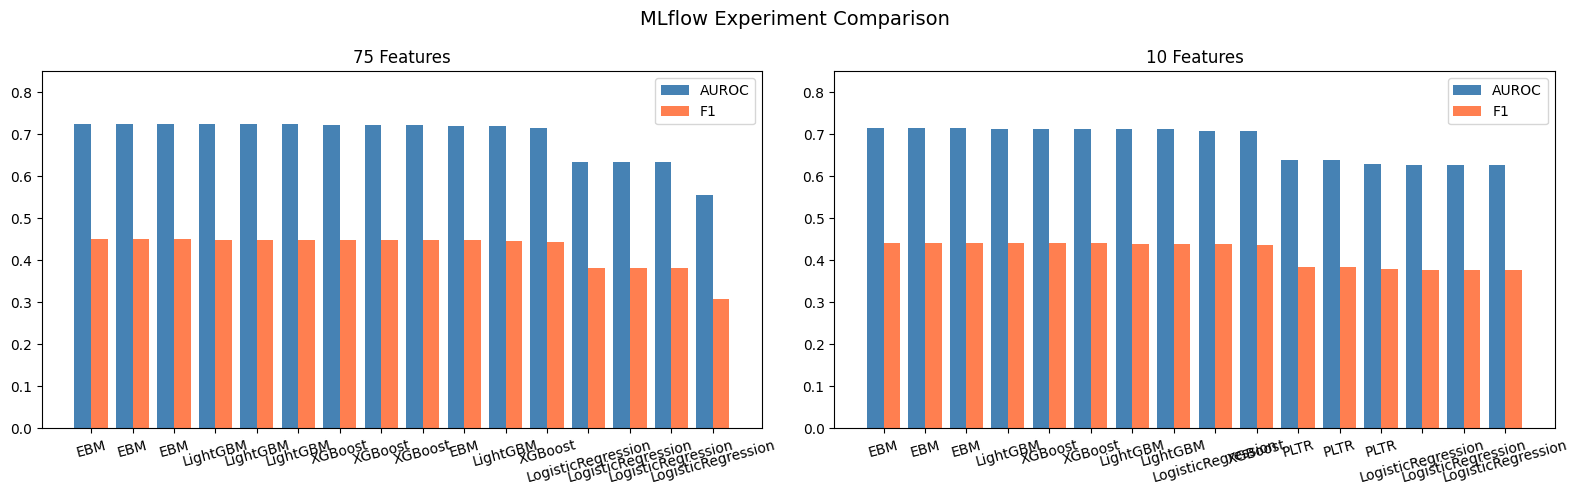

In [5]:
# Compare experiments side by side
client = MlflowClient()

print("=== Experiment: baseline-75-features ===")
exp_75 = client.get_experiment_by_name("baseline-75-features")
runs_75 = client.search_runs(exp_75.experiment_id, order_by=["metrics.AUROC DESC"])
for r in runs_75:
    print(f"  {r.data.tags.get('mlflow.runName', '?'):20s}  AUROC={r.data.metrics.get('AUROC', 0):.4f}  F1={r.data.metrics.get('F1', 0):.4f}")

print("\n=== Experiment: reduced-10-features ===")
exp_10 = client.get_experiment_by_name("reduced-10-features")
runs_10 = client.search_runs(exp_10.experiment_id, order_by=["metrics.AUROC DESC"])
for r in runs_10:
    print(f"  {r.data.tags.get('mlflow.runName', '?'):20s}  AUROC={r.data.metrics.get('AUROC', 0):.4f}  F1={r.data.metrics.get('F1', 0):.4f}")

# Visualization: experiment comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (title, runs) in zip(axes, [("75 Features", runs_75), ("10 Features", runs_10)]):
    names = [r.data.tags.get("mlflow.runName", "?") for r in runs]
    aurocs = [r.data.metrics.get("AUROC", 0) for r in runs]
    f1s = [r.data.metrics.get("F1", 0) for r in runs]
    x = np.arange(len(names))
    ax.bar(x - 0.2, aurocs, 0.4, label="AUROC", color="steelblue")
    ax.bar(x + 0.2, f1s, 0.4, label="F1", color="coral")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_title(title); ax.legend(); ax.set_ylim(0, 0.85)
plt.suptitle("MLflow Experiment Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "mlflow_experiment_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6.3 Model Registry

Register the best models with aliases to track the lifecycle:
- EBM v1 (75 features) → registered, then archived
- EBM v2 (10 features) → promoted to **champion** (production)
- XGB v2 (10 features) → registered as **challenger** (staging)

In [6]:
client = MlflowClient()

# --- Register EBM v1 (75 features) ---
mv_ebm_v1 = mlflow.register_model(f"runs:/{run_id_ebm_75}/model", "credit-scoring-ebm")
client.update_model_version(
    name="credit-scoring-ebm",
    version=mv_ebm_v1.version,
    description="EBM trained on all 75 features. AUROC=0.721. Baseline model.",
)
print(f"Registered credit-scoring-ebm v{mv_ebm_v1.version} (75 features)")

# --- Register EBM v2 (10 features) ---
mv_ebm_v2 = mlflow.register_model(f"runs:/{run_id_ebm_10}/model", "credit-scoring-ebm")
client.update_model_version(
    name="credit-scoring-ebm",
    version=mv_ebm_v2.version,
    description="EBM on top 10 SHAP features. AUROC=0.714. 86.7% feature reduction, <1% AUROC drop. Full interpretability.",
)
# Promote v2 to champion (production)
client.set_registered_model_alias("credit-scoring-ebm", "champion", mv_ebm_v2.version)
print(f"Registered credit-scoring-ebm v{mv_ebm_v2.version} (10 features) → champion")

# --- Register XGB v2 (10 features) as challenger ---
mv_xgb_v2 = mlflow.register_model(f"runs:/{run_id_xgb_10}/model", "credit-scoring-xgb")
client.update_model_version(
    name="credit-scoring-xgb",
    version=mv_xgb_v2.version,
    description="XGBoost on top 10 features. AUROC=0.707. Challenger model.",
)
client.set_registered_model_alias("credit-scoring-xgb", "challenger", mv_xgb_v2.version)
print(f"Registered credit-scoring-xgb v{mv_xgb_v2.version} (10 features) → challenger")

print("\n=== Model Registry Summary ===")
for name in ["credit-scoring-ebm", "credit-scoring-xgb"]:
    rm = client.get_registered_model(name)
    print(f"\n{name}:")
    for mv in rm.latest_versions:
        print(f"  v{mv.version}: {mv.description[:80]}")
    for alias in rm.aliases:
        v = client.get_model_version_by_alias(name, alias)
        print(f"  @{alias} → v{v.version}")

Registered model 'credit-scoring-ebm' already exists. Creating a new version of this model...
2026/04/19 20:00:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 4fb601f7ff694035b4b10ba50974c5cd has no artifacts at artifact path 'model', registering model based on models:/m-d68793f394b846d285ac0d55026377ab instead


Created version '5' of model 'credit-scoring-ebm'.
Registered model 'credit-scoring-ebm' already exists. Creating a new version of this model...
2026/04/19 20:00:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 07661d2db5f34624a3134bb316a750ad has no artifacts at artifact path 'model', registering model based on models:/m-83cfb12f0fda48f989d7b4636f382b9c instead


Created version '6' of model 'credit-scoring-ebm'.
Registered model 'credit-scoring-xgb' already exists. Creating a new version of this model...
2026/04/19 20:00:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 51ea0ace12134043b6cbc525fbf8b372 has no artifacts at artifact path 'model', registering model based on models:/m-fbe1a55375c043c89b1dc76f6d9b448a instead


Created version '3' of model 'credit-scoring-xgb'.


Registered credit-scoring-ebm v5 (75 features)
Registered credit-scoring-ebm v6 (10 features) → champion
Registered credit-scoring-xgb v3 (10 features) → challenger

=== Model Registry Summary ===

credit-scoring-ebm:
  v6: EBM on top 10 SHAP features. AUROC=0.714. 86.7% feature reduction, <1% AUROC dro
  @champion → v6

credit-scoring-xgb:
  v3: XGBoost on top 10 features. AUROC=0.707. Challenger model.
  @challenger → v3


=== EBM Version Comparison (Promotion Rationale) ===
                        v1 (75 feat)    v2 (10 feat)     Change
-----------------------------------------------------------------
AUROC                         0.7248          0.7142     -1.47%
AUPRC                         0.4052          0.3902     -3.71%
F1                            0.4518          0.4421     -2.13%
Balanced Accuracy             0.6628          0.6556     -1.10%
Features                          75              10     -86.7%
Interpretable                Partial            Full

Decision: Promote v2 to production — near-identical performance
with full interpretability and 86.7% feature reduction.


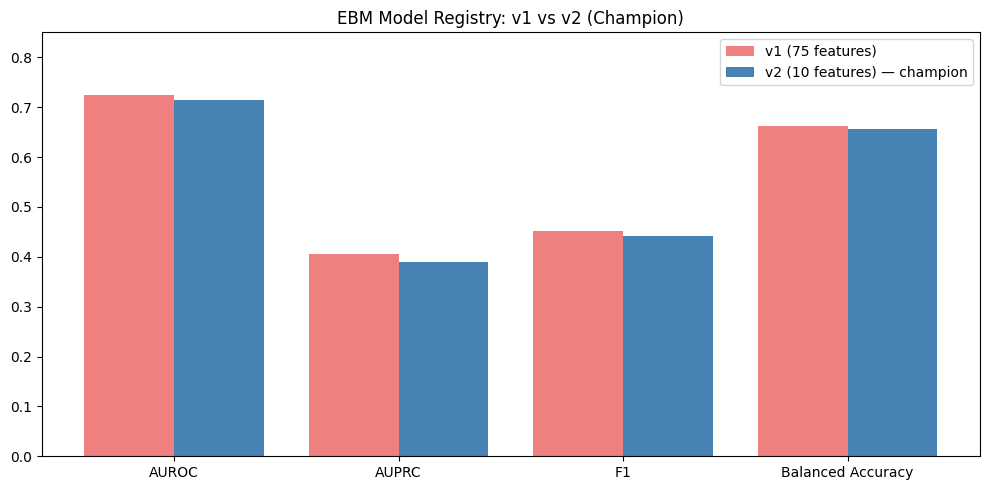

In [7]:
# Compare v1 vs v2 — the promotion rationale
print("=== EBM Version Comparison (Promotion Rationale) ===")
print(f"{'':20s} {'v1 (75 feat)':>15s} {'v2 (10 feat)':>15s} {'Change':>10s}")
print("-" * 65)

# Get metrics from MLflow runs
r_v1 = client.get_run(run_id_ebm_75)
r_v2 = client.get_run(run_id_ebm_10)

for metric in ["AUROC", "AUPRC", "F1", "Balanced Accuracy"]:
    m1 = r_v1.data.metrics[metric]
    m2 = r_v2.data.metrics[metric]
    pct = (m2 - m1) / m1 * 100
    print(f"{metric:20s} {m1:15.4f} {m2:15.4f} {pct:+9.2f}%")

print(f"{'Features':20s} {'75':>15s} {'10':>15s} {'-86.7%':>10s}")
print(f"{'Interpretable':20s} {'Partial':>15s} {'Full':>15s}")
print("\nDecision: Promote v2 to production — near-identical performance")
print("with full interpretability and 86.7% feature reduction.")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = ["AUROC", "AUPRC", "F1", "Balanced Accuracy"]
v1_vals = [r_v1.data.metrics[m] for m in metrics_names]
v2_vals = [r_v2.data.metrics[m] for m in metrics_names]
x = np.arange(len(metrics_names))
ax.bar(x - 0.2, v1_vals, 0.4, label="v1 (75 features)", color="lightcoral")
ax.bar(x + 0.2, v2_vals, 0.4, label="v2 (10 features) — champion", color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_title("EBM Model Registry: v1 vs v2 (Champion)")
ax.legend(); ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "model_registry_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6.4 Data Drift Monitoring — Pre-computation

Analyze how the test data (2016–2018) drifts from the training data (≤2015).
- **Temporal drift**: slice test set by year, compute PSI and KS per feature
- **Performance degradation**: EBM metrics per year
- **Save artifacts**: for the Streamlit monitoring dashboard

In [8]:
# Reload raw data to get issue dates (dropped during preprocessing)
from src.data import load_raw, define_target

df_raw = load_raw(DATA_DIR)
df_raw = define_target(df_raw)
df_raw["issue_d"] = pd.to_datetime(df_raw["issue_d"], format="%b-%Y")

# Extract test period dates (same temporal split as notebook 01)
train_cutoff = pd.to_datetime("Jul-2015", format="%b-%Y")
test_cutoff = pd.to_datetime("Dec-2018", format="%b-%Y")
test_mask = (df_raw["issue_d"] > train_cutoff) & (df_raw["issue_d"] <= test_cutoff)
test_dates = df_raw.loc[test_mask, "issue_d"]

# Verify alignment with processed data
assert len(test_dates) == len(X_test), f"Date count {len(test_dates)} != X_test rows {len(X_test)}"
year_labels = test_dates.dt.year.values
print(f"Test set year distribution:")
for yr in [2015, 2016, 2017, 2018]:
    n = (year_labels == yr).sum()
    if n > 0:
        print(f"  {yr}: {n:,} rows")

# Also get test targets aligned with years
test_targets = df_raw.loc[test_mask, "target"].values

# Compute PSI and KS for each year vs training data (top 10 features only)
drift_rows = []
for yr in [2016, 2017, 2018]:
    yr_mask = year_labels == yr
    X_yr = X_test_10[yr_mask]
    report = compute_drift_report(X_train_10, X_yr, top10)
    report["year"] = yr
    drift_rows.append(report)

drift_temporal = pd.concat(drift_rows, ignore_index=True)
drift_temporal.to_csv(os.path.join(REPORTS_DIR, "drift_temporal.csv"), index=False)
print(f"\nSaved drift_temporal.csv ({len(drift_temporal)} rows)")
print(drift_temporal.pivot(index="feature", columns="year", values="psi").to_string())
# Summarise drift across all years and features
from src.drift import drift_summary
drift_df = drift_temporal.copy()
summary = drift_summary(drift_df)
print("Drift summary:", summary)
# Log drift summary as MLflow metrics if inside an active run
try:
    import mlflow
    if mlflow.active_run() is not None:
        mlflow.log_metric("drift_count_significant", summary["counts_per_level"]["significant"])
        mlflow.log_metric("drift_any_significant", int(summary["any_significant"]))
except Exception as _e:
    print(f"(Skipping drift MLflow metric logging: {_e})")

Test set year distribution:
  2015: 181,810 rows
  2016: 403,032 rows
  2017: 314,212 rows
  2018: 197,074 rows



Saved drift_temporal.csv (30 rows)
year                    2016    2017    2018
feature                                     
acc_open_past_24mths  0.0189  0.0122  0.0220
annual_inc            0.0084  0.0110  0.0140
avg_cur_bal           0.0007  0.0026  0.0118
dti                   0.0124  0.0088  0.0343
fico                  0.0019  0.0206  0.1136
int_rate              0.1180  0.1086  0.1771
loan_amnt             0.0163  0.0424  0.0538
term                  0.0451  0.0298  0.0035
tot_hi_cred_lim       0.0047  0.0094  0.0177
total_bc_limit        0.0047  0.0221  0.0611
Drift summary: {'counts_per_level': {'no_drift': 26, 'moderate': 4, 'significant': 0}, 'any_significant': False}


In [9]:
# Model performance per year (using champion model: EBM on 10 features)
X_slices = {}
y_slices = {}
for yr in [2016, 2017, 2018]:
    yr_mask = year_labels == yr
    X_slices[str(yr)] = X_test_10[yr_mask]
    y_slices[str(yr)] = pd.Series(test_targets[yr_mask])

drift_perf = compute_performance_over_time(ebm_10, X_slices, y_slices, threshold=t_ebm)
drift_perf.to_csv(os.path.join(REPORTS_DIR, "drift_performance.csv"), index=False)
print("Performance over time (EBM champion):")
print(drift_perf[["period", "AUROC", "F1", "default_rate", "n_samples"]].to_string(index=False))

Performance over time (EBM champion):
period    AUROC       F1  default_rate  n_samples
  2016 0.717715 0.428818        0.1960     403032
  2017 0.707474 0.437889        0.2103     314212
  2018 0.704287 0.470076        0.2391     197074


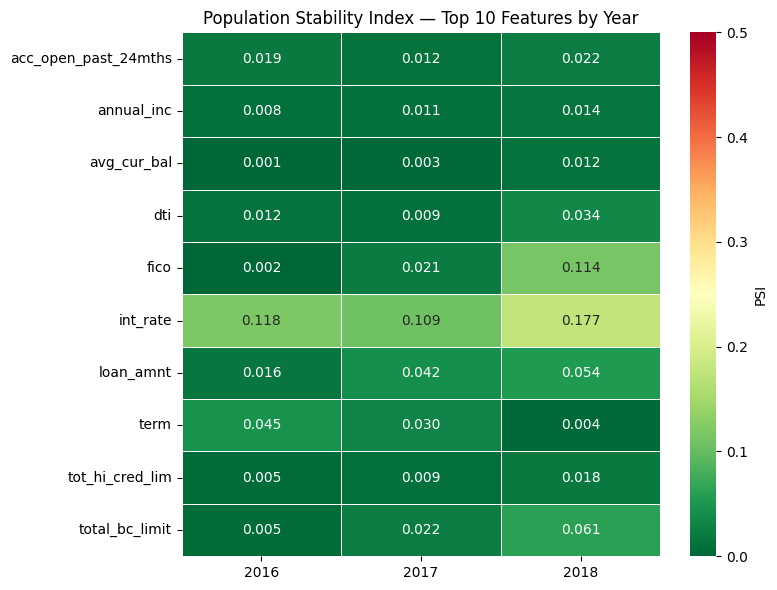

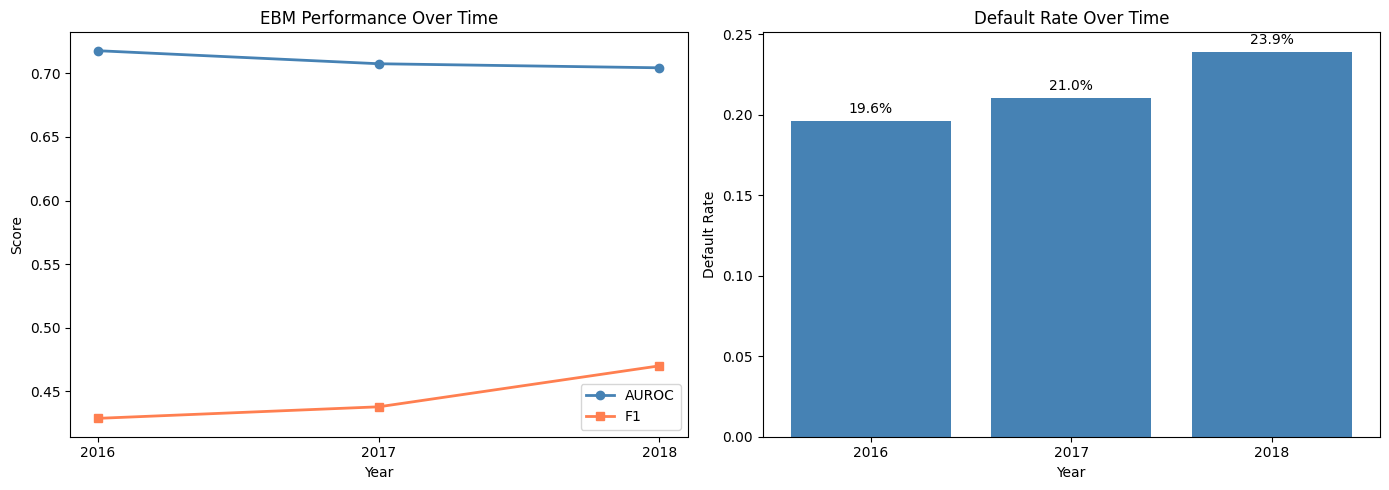

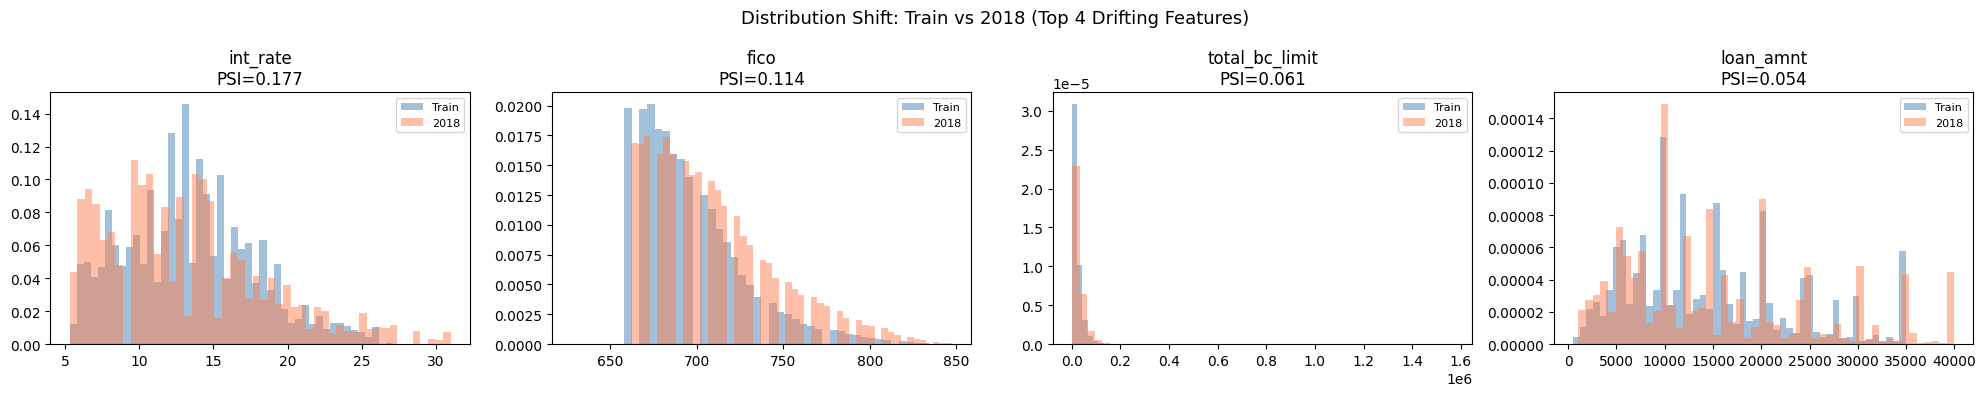

In [10]:
# PSI Heatmap
pivot = drift_temporal.pivot(index="feature", columns="year", values="psi")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax, vmin=0, vmax=0.5,
            linewidths=0.5, cbar_kws={"label": "PSI"})
ax.set_title("Population Stability Index — Top 10 Features by Year")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "drift_psi_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Performance trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(drift_perf["period"], drift_perf["AUROC"], "o-", label="AUROC", color="steelblue", linewidth=2)
ax.plot(drift_perf["period"], drift_perf["F1"], "s-", label="F1", color="coral", linewidth=2)
ax.set_title("EBM Performance Over Time")
ax.set_ylabel("Score"); ax.set_xlabel("Year"); ax.legend()

ax = axes[1]
ax.bar(drift_perf["period"], drift_perf["default_rate"], color="steelblue")
ax.set_title("Default Rate Over Time")
ax.set_ylabel("Default Rate"); ax.set_xlabel("Year")
for i, row in drift_perf.iterrows():
    ax.text(i, row["default_rate"] + 0.005, f"{row['default_rate']:.1%}", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "drift_performance_trend.png"), dpi=150, bbox_inches="tight")
plt.show()

# Distribution overlays for top drifting features (most shifted by PSI in 2018)
top_drift = drift_temporal[drift_temporal["year"] == 2018].nlargest(4, "psi")
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
yr_mask_2018 = year_labels == 2018
for ax, (_, row) in zip(axes, top_drift.iterrows()):
    feat = row["feature"]
    ax.hist(X_train_10[feat], bins=50, alpha=0.5, density=True, label="Train", color="steelblue")
    ax.hist(X_test_10[yr_mask_2018][feat], bins=50, alpha=0.5, density=True, label="2018", color="coral")
    ax.set_title(f"{feat}\nPSI={row['psi']:.3f}")
    ax.legend(fontsize=8)
plt.suptitle("Distribution Shift: Train vs 2018 (Top 4 Drifting Features)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "drift_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Save reference samples for the Streamlit monitoring tab
rng = np.random.RandomState(42)
sample_size = 5000

# Training reference sample
train_sample = X_train_10.iloc[rng.choice(len(X_train_10), sample_size, replace=False)].copy()
train_sample["period"] = "train"

# Per-year test samples
year_samples = []
for yr in [2016, 2017, 2018]:
    yr_mask = year_labels == yr
    yr_indices = np.where(yr_mask)[0]
    sample_idx = rng.choice(yr_indices, min(sample_size, len(yr_indices)), replace=False)
    sample = X_test_10.iloc[sample_idx].copy()
    sample["period"] = str(yr)
    year_samples.append(sample)

drift_samples = pd.concat([train_sample] + year_samples, ignore_index=True)
drift_samples.to_csv(os.path.join(REPORTS_DIR, "drift_samples.csv"), index=False)
print(f"Saved drift_samples.csv: {drift_samples.shape}")
print(f"Periods: {drift_samples['period'].value_counts().to_dict()}")

print("\n=== Phase 6 complete. ===")
print("Run 'mlflow ui' from project root to explore experiments.")
print("Run 'streamlit run app/dashboard.py' for the full dashboard with monitoring.")

Saved drift_samples.csv: (20000, 11)
Periods: {'train': 5000, '2016': 5000, '2017': 5000, '2018': 5000}

=== Phase 6 complete. ===
Run 'mlflow ui' from project root to explore experiments.
Run 'streamlit run app/dashboard.py' for the full dashboard with monitoring.
